In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pybamm
import liionpack as lp

Minimum Viable Product:

1. Battery Pack of LG M50 Batteries w/ Parameters from Chen2020 Dataset
(Use liionpack to describe circuit configuration)

2. A way to represent both charge/discharge data (solar panel power production & system loads),
and run experiments with that data

3. A way to plot relevant pack variables against each other

3. Validation against a test datasheet for our specific battery (LG MJ 1)
    
5. Battery degradation, either through a physics-based mechanism, or through some other
rule (need to further consult PyBaMM Docs for more info on this)

Things that would be nice:

1. Consideration of thermal effects based

In [2]:
# Some preliminary example functions for charging and load data

# roughly square wave function, plus some smoothing
def power_wave(input_times, period=1, time_on=0.6, amplitude=1):
    normalized_time = (input_times % period) / period
    return amplitude * np.heaviside(normalized_time - (1 - time_on), 0.5)


In [3]:
# Currently, charging_data[i] is the current being provided by the solar panels,
# from (10*i) seconds to 10*(i+1) seconds, and likewise load_data[i] is the
# discharge current from time = 10*i to time = 10(i+1)

num_orbits = 20

orbit_duration = 90 # minutes
sampling_rate = 1 # updates / min

times = np.linspace(0, num_orbits * orbit_duration, num_orbits * orbit_duration * sampling_rate)

# Assuming we get 1.4 A from panels,
# and load is either 1.02 A (eclipse) or 0.6 A (sun), depending on whether heaters are on
net_charge = power_wave(times, period=orbit_duration, time_on=0.61, amplitude=0.5) - 0.4


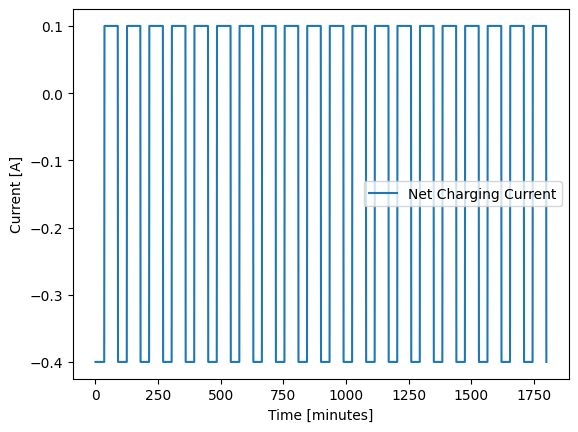

In [4]:
plt.plot(times, net_charge, label="Net Charging Current")
plt.xlabel("Time [minutes]")
plt.ylabel("Current [A]")
plt.legend()
plt.show()

In [5]:
# Pick a set of Parameters (Until something better comes along, we will use Chen 2020)
# params = pybamm.ParameterValues('NCA_Kim2011')
# params = pybamm.ParameterValues('Chen2020')
params = pybamm.ParameterValues("OKane2022")


start_voltage = params['Open-circuit voltage at 100% SOC [V]'] * 0.5

# TODO: I think we should also add an initial short circuit current?

In [6]:
print(params)
print(len(params.keys()))

{'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.2594,
 'Cell cooling surface area [m2]': 0.00531,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 2.42e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': 5.0,
 'Dead lithium decay constant [s-1]': 1e-06,
 'Dead lithium decay rate [s-1]': <function SEI_limited_dead_lithium_OKane2022 at 0x0000022B8A1BD280>,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Electrode height [m]': 0.065,
 'Electrode width [m]': 1.58,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Nyman2008_arrhenius at 0x0000022B8D372E50>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Nyman2008_arrhenius at 0x0000022B8D372DC0>,
 'Electron charge [C]': 1.602176634e-19,
 'Exchange-current density for plating [A.m-2]': <function 

In [7]:
params.update({'Lower voltage cut-off [V]': 2.0})
print(params['Lower voltage cut-off [V]'])

2.0


In [8]:
# Relevant Chen2020 parameters we can consider tweaking are:
# 'Current function [A]
# 'Nominal cell capacity [A.h]'
# 'Upper voltage cut-off [V]'
# 'Open-circuit voltage at 100% SOC [V]'

# In particular, we should compare these parameters (which are for the LG M50) to our battery

In [9]:
# Initialize pack configuration

series = 6
parallel = 1
num_cells = series * parallel

oc_voltage_init = series * start_voltage

# i_mag = 8.0 
# TODO: I know this is the value of a current source in the circuit diagram, but IDK what it does

i_mag = 2.0

wire_resistance = 1e-3 # internal resistance of connections between batteries

netlist = lp.setup_circuit(Np=parallel, Ns=series, 
                           Rb=wire_resistance, Rc=wire_resistance, Ri=wire_resistance,
                           V=oc_voltage_init, I=i_mag)

In [10]:
# Setup an experiment that accurately represents subsystem loads and power we're getting

experiment = pybamm.Experiment(
    [
        (
            f"Discharge at {-current} A for {60 / sampling_rate} seconds",
        ) if current < 0 else (
            f"Charge at {current} A for {60 / sampling_rate} seconds",
        ) for current in net_charge
    ],
    period = f"{60 / sampling_rate} seconds" # good practice to have this the same as 60 / sampling rate
)

# TODO add extra simulation params to get something more realistic - check documentation

In [11]:
def sim_func(params):
    '''Takes parameter values and returns a simulation object'''
    dfn_model = pybamm.models.full_battery_models.lithium_ion.DFN(
        options={"lithium plating": "irreversible"}
    )
    simulation = pybamm.Simulation(
        model=dfn_model,
        parameter_values=params
    )
    return simulation

Stepping simulation: 100%|██████████| 1801/1801 [00:15<00:00, 117.94it/s]


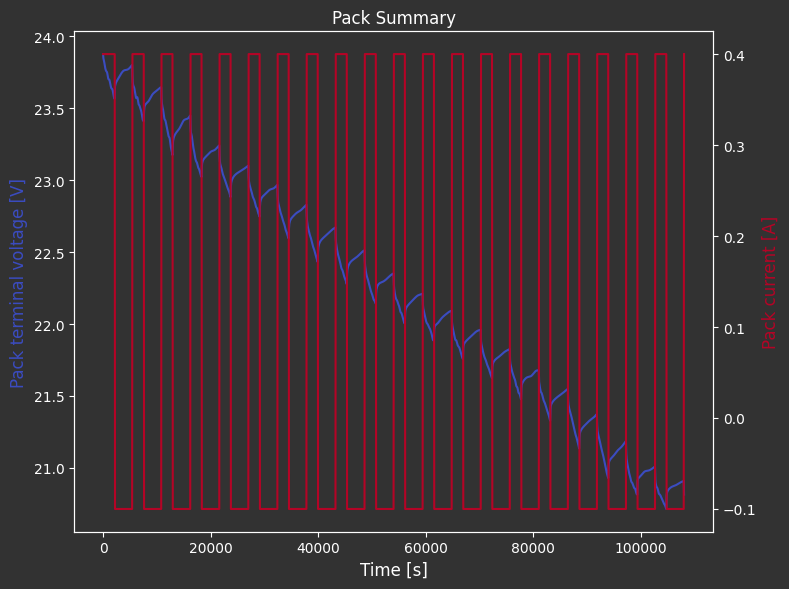

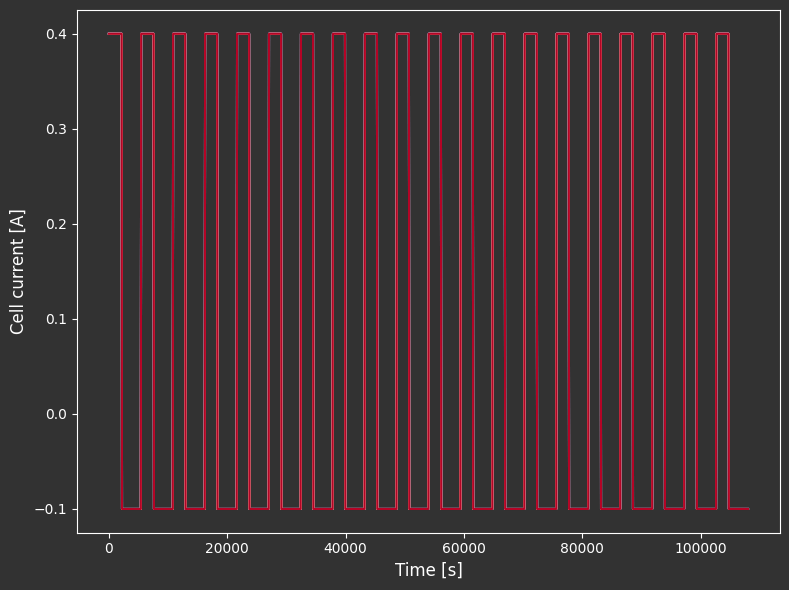

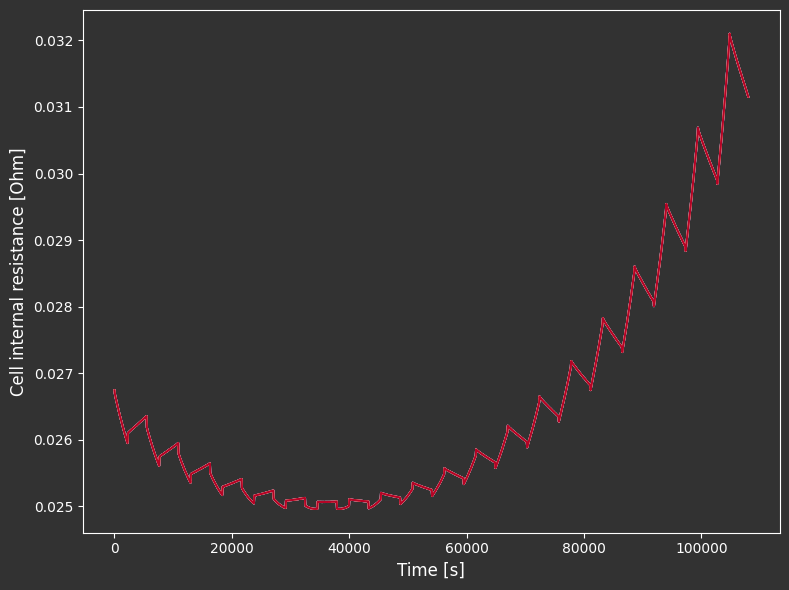

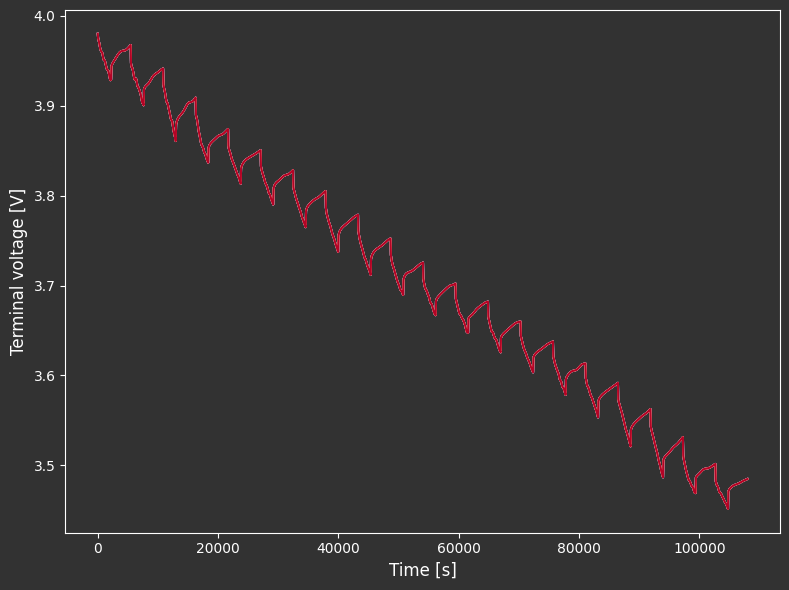

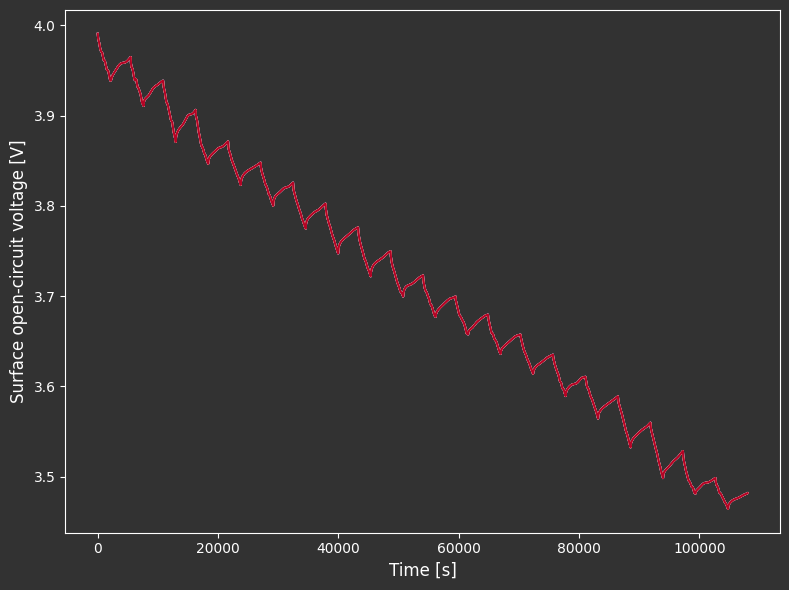

In [12]:
# Create a simulation for the experiment, solve it, then plot some useful stuff

# TODO: currently this does nothing - figure out how to add (non default) model to solver
# SPMe = pybamm.models.full_battery_models.lithium_ion.SPMe() 
# dfn = pybamm.models.full_battery_models.lithium_ion.DFN(options={"lithium plating": "irreversible"})

output = lp.solve(
    netlist=netlist,
    # sim_func=sim_func,
    parameter_values=params,
    experiment=experiment,
    initial_soc=0.75
)

lp.plot_output(output)

Stepping simulation: 100%|██████████| 11/11 [00:00<00:00, 125.30it/s]


✓ Simple configuration works!


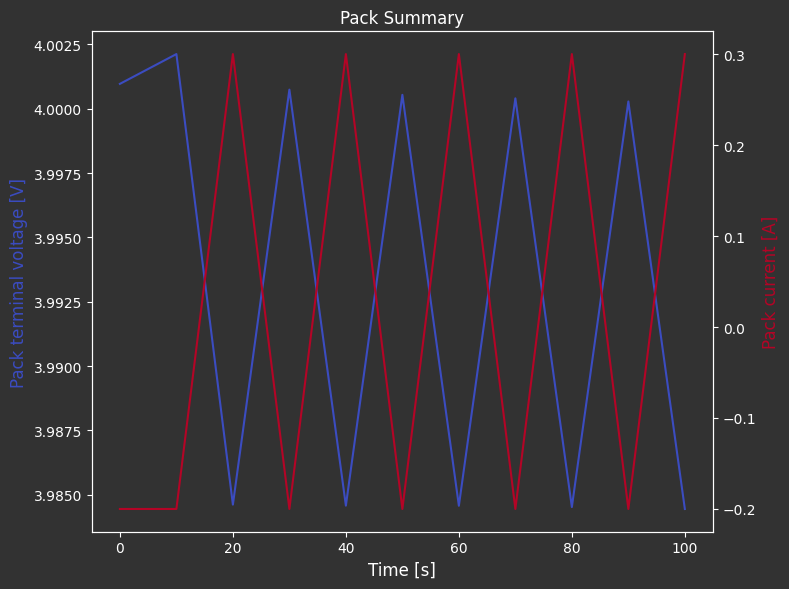

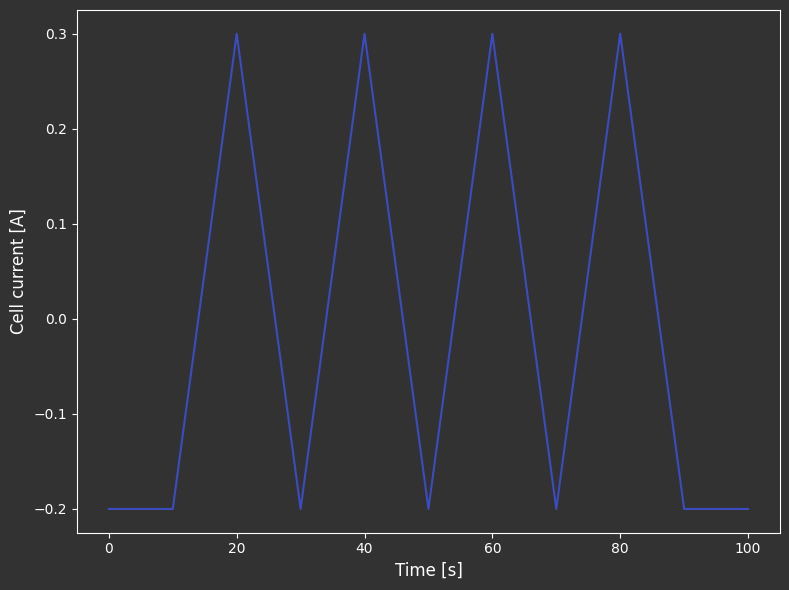

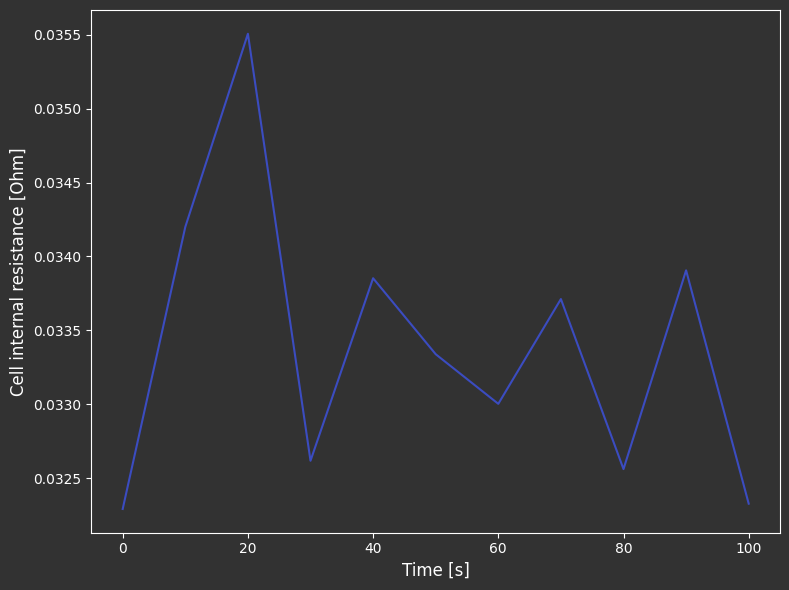

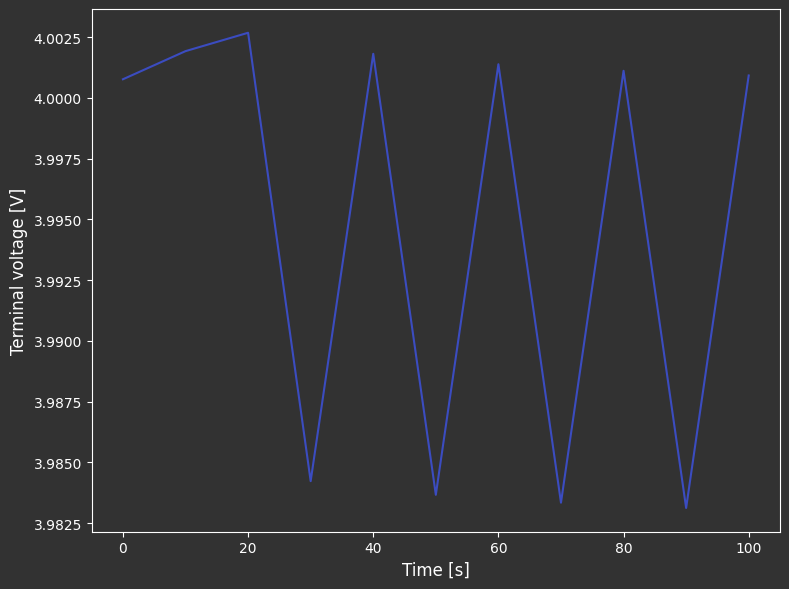

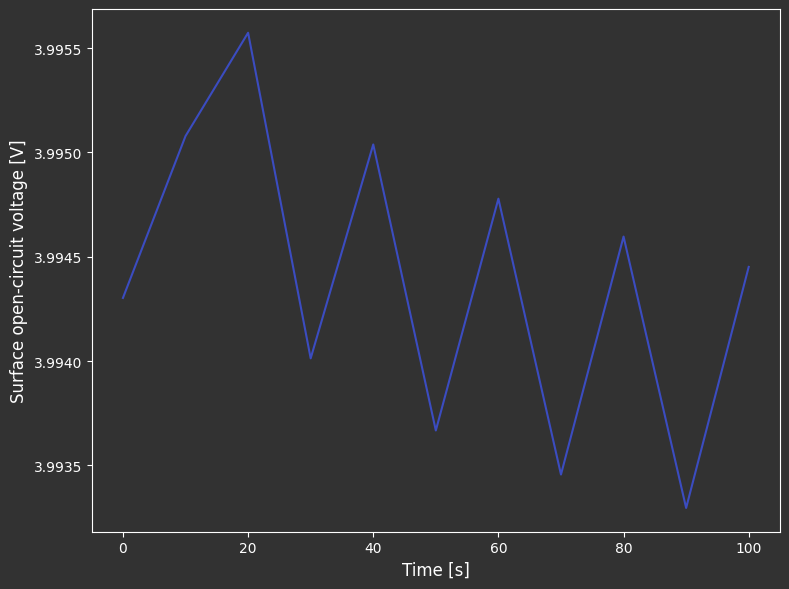

In [13]:
# DEBUGGING: Try a simpler configuration first
# Let's test with: SPMe model, Chen2020 params, simpler experiment, single battery

# Use Chen2020 instead of OKane2022
test_params = pybamm.ParameterValues('Chen2020')

# Single battery pack for testing
test_netlist = lp.setup_circuit(Np=1, Ns=1, Rb=1e-3, Rc=1e-3, Ri=1e-3, 
                                 V=test_params['Open-circuit voltage at 100% SOC [V]'] * 0.5, 
                                 I=1.0)

# Simple experiment - just a few cycles
simple_experiment = pybamm.Experiment([
    "Charge at 0.2 A for 10 seconds",
    "Discharge at 0.3 A for 10 seconds",
] * 5,  # Repeat 5 times
    period="10 seconds"
)

# Simpler model without lithium plating
def test_sim_func(params):
    model = pybamm.models.full_battery_models.lithium_ion.SPMe()  # Simpler than DFN
    simulation = pybamm.Simulation(model=model, parameter_values=params)
    return simulation

# Try solving
try:
    test_output = lp.solve(
        netlist=test_netlist,
        sim_func=test_sim_func,
        parameter_values=test_params,
        experiment=simple_experiment,
        initial_soc=0.75
    )
    print("✓ Simple configuration works!")
    lp.plot_output(test_output)
except Exception as e:
    print(f"✗ Simple configuration failed: {e}")


Stepping simulation: 100%|██████████| 1801/1801 [00:16<00:00, 106.64it/s]


✓ Full simulation with Chen2020 + SPMe works!


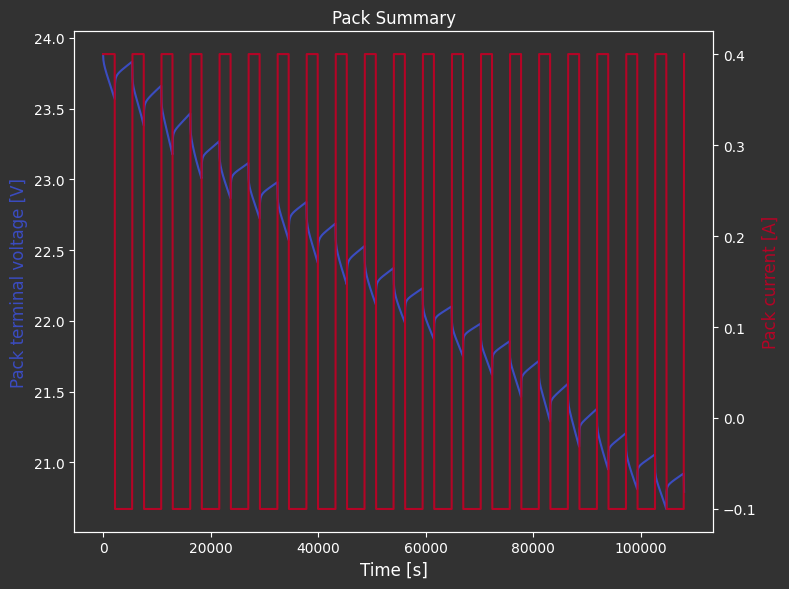

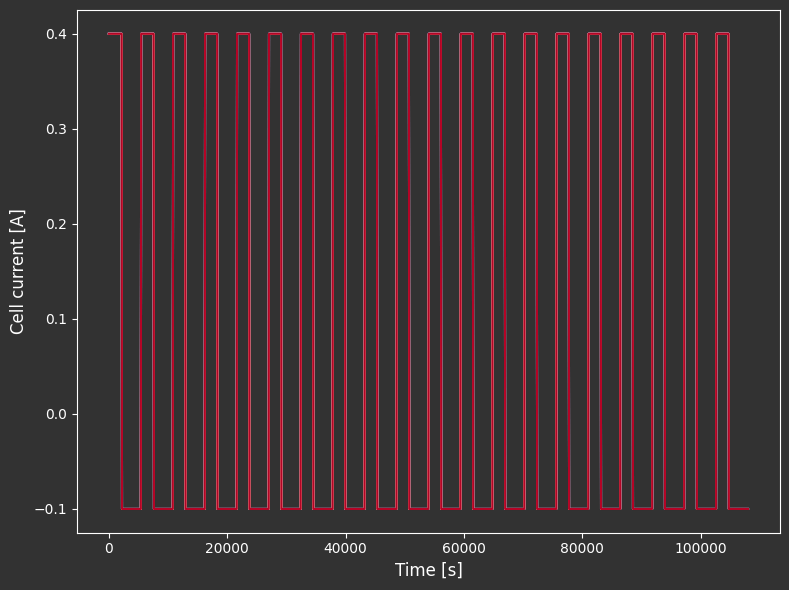

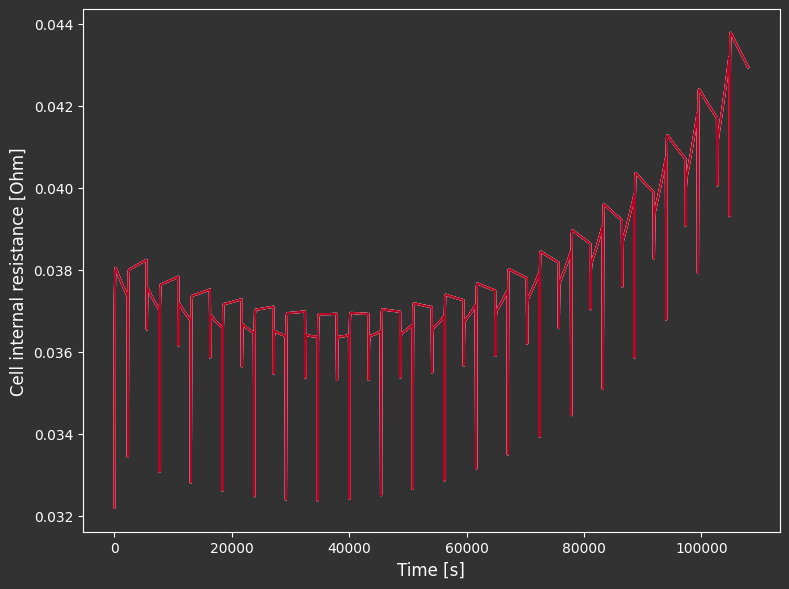

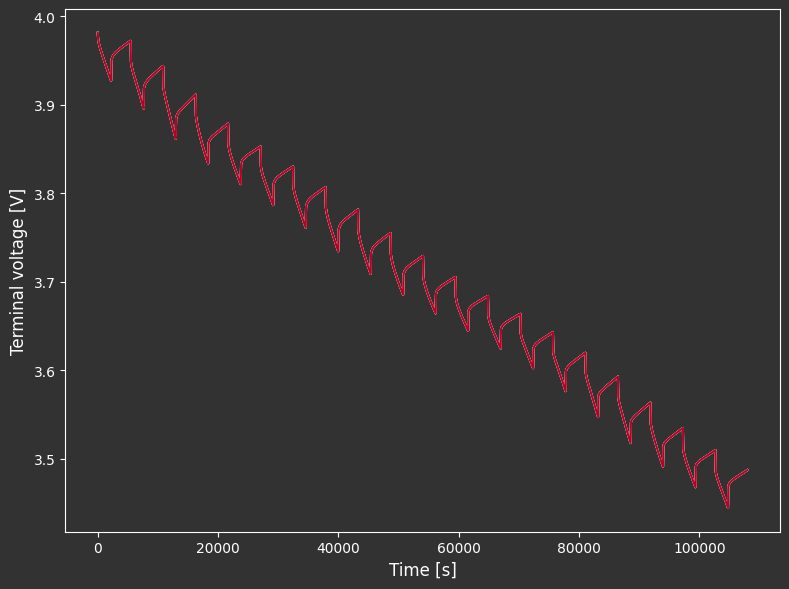

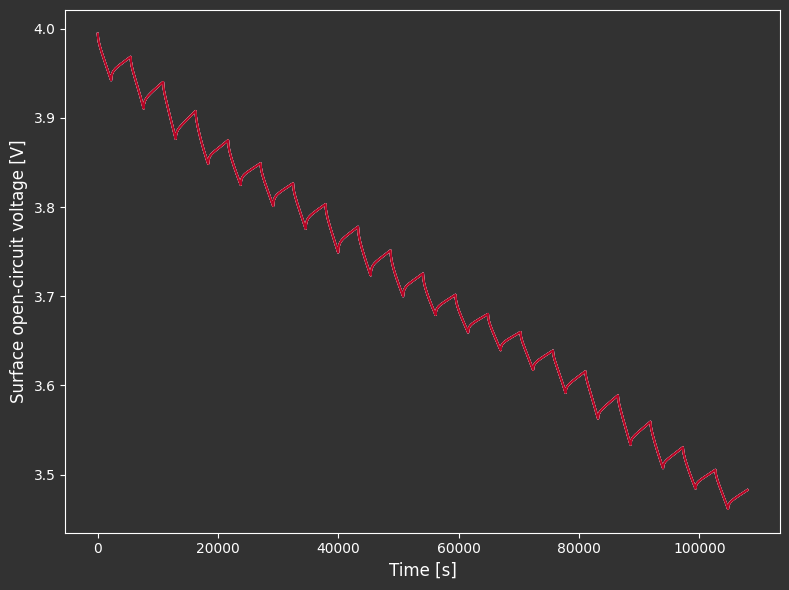

In [14]:
# If simple test works, try your original setup with Chen2020 parameters instead
# This is a common parameter set that works well with liionpack

params_chen = pybamm.ParameterValues('Chen2020')
params_chen.update({'Lower voltage cut-off [V]': 2.0})

# Also try with SPMe instead of DFN (faster and more stable)
def sim_func_spme(params):
    '''SPMe model - simpler and more stable than DFN'''
    model = pybamm.models.full_battery_models.lithium_ion.SPMe()
    simulation = pybamm.Simulation(model=model, parameter_values=params)
    return simulation

# Try with your full experiment but Chen2020 params and SPMe model
try:
    output_fixed = lp.solve(
        netlist=netlist,
        sim_func=sim_func_spme,
        parameter_values=params_chen,
        experiment=experiment,
        initial_soc=0.75
    ) 
    print("✓ Full simulation with Chen2020 + SPMe works!")
    lp.plot_output(output_fixed)
except Exception as e:
    print(f"✗ Still failing: {e}")


In [15]:
# If simple test works, try your original setup with Chen2020 parameters instead
# This is a common parameter set that works well with liionpack

params_chen = pybamm.ParameterValues('Chen2020')
params_chen.update({'Lower voltage cut-off [V]': 2.0})

# Also try with SPMe instead of DFN (faster and more stable)
def sim_func_spme(params):
    '''SPMe model - simpler and more stable than DFN'''
    model = pybamm.models.full_battery_models.lithium_ion.SPMe(options={"lithium plating": "irreversible"})
    simulation = pybamm.Simulation(model=model, parameter_values=params)
    return simulation

# Try with your full experiment but Chen2020 params and SPMe model
try:
    output_fixed = lp.solve(
        netlist=netlist,
        sim_func=sim_func_spme,
        parameter_values=params_chen,
        experiment=experiment,
        initial_soc=0.75
    ) 
    print("✓ Full simulation with Chen2020 + SPMe works!")
    lp.plot_output(output_fixed)
except Exception as e:
    print(f"✗ Still failing: {e}")

✗ Still failing: "'Exchange-current density for plating [A.m-2]' not found. Best matches are ['SEI reaction exchange current density [A.m-2]', 'Positive electrode exchange-current density [A.m-2]', 'Negative electrode exchange-current density [A.m-2]']"
